# Welcome to Colab!

In [7]:
from google.colab import drive
drive.mount('/content/drive')

import requests, json, os, tarfile, time
import pandas as pd
from pathlib import Path

base = "/content/drive/MyDrive/brca_project"
os.makedirs(f"{base}/counts", exist_ok=True)
os.makedirs(f"{base}/clinical", exist_ok=True)

print("ready")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ready


In [8]:
filters = {
    "op": "and",
    "content": [
        {"op": "in", "content": {"field": "cases.project.project_id", "value": ["TCGA-BRCA"]}},
        {"op": "in", "content": {"field": "data_type", "value": ["Gene Expression Quantification"]}},
        {"op": "in", "content": {"field": "analysis.workflow_type", "value": ["STAR - Counts"]}}
    ]
}

all_hits = []
for from_idx in range(0, 1300, 100):
    params = {
        "filters": json.dumps(filters),
        "fields": "file_id,file_name,cases.submitter_id,cases.samples.sample_type",
        "format": "JSON",
        "size": "100",
        "from": str(from_idx)
    }
    r = requests.get("https://api.gdc.cancer.gov/files", params=params)
    hits = r.json()["data"]["hits"]
    if not hits:
        break
    all_hits.extend(hits)

print("total files:", len(all_hits))

total files: 1231


In [9]:
rows = []
for h in all_hits:
    rows.append({
        "file_id": h["file_id"],
        "file_name": h["file_name"],
        "case_id": h["cases"][0]["submitter_id"],
        "sample_type": h["cases"][0]["samples"][0]["sample_type"]
    })

meta = pd.DataFrame(rows)

# subset to 100 tumor + 50 normal
tumor = meta[meta["sample_type"] == "Primary Tumor"].sample(100, random_state=42)
normal = meta[meta["sample_type"] == "Solid Tissue Normal"].sample(50, random_state=42)
meta = pd.concat([tumor, normal]).reset_index(drop=True)

print(meta["sample_type"].value_counts())

sample_type
Primary Tumor          100
Solid Tissue Normal     50
Name: count, dtype: int64


In [10]:
def download_and_extract(file_ids, batch_num, extract_to):
    marker = f"{extract_to}/.batch_{batch_num}_done"
    if os.path.exists(marker):
        print(f"batch {batch_num} already done, skipping")
        return

    tar_path = f"{extract_to}/tmp_{batch_num}.tar.gz"

    for attempt in range(3):
        try:
            resp = requests.post(
                "https://api.gdc.cancer.gov/data",
                json={"ids": file_ids},
                stream=True,
                timeout=600
            )
            with open(tar_path, "wb") as f:
                for chunk in resp.iter_content(chunk_size=1024*1024):
                    if chunk:
                        f.write(chunk)

            with tarfile.open(tar_path) as tar:
                tar.extractall(extract_to)

            os.remove(tar_path)
            open(marker, "w").close()
            print(f"batch {batch_num} done")
            return

        except Exception as e:
            print(f"batch {batch_num} attempt {attempt+1} failed: {e}")
            time.sleep(15)

    print(f"batch {batch_num} gave up")


all_ids = meta["file_id"].tolist()
batches = [all_ids[i:i+25] for i in range(0, len(all_ids), 25)]  # smaller batches
print(f"{len(batches)} batches to download")

for i, batch in enumerate(batches):
    download_and_extract(batch, i, f"{base}/counts")
    time.sleep(5)  # slightly longer pause

print("all done")

6 batches to download
batch 0 already done, skipping
batch 1 already done, skipping
batch 2 already done, skipping
batch 3 already done, skipping
batch 4 already done, skipping
batch 5 already done, skipping
all done


In [11]:
count_dict = {}

for root, dirs, files in os.walk(f"{base}/counts"):
    for f in files:
        if not f.endswith(".tsv"):
            continue

        filepath = os.path.join(root, f)
        folder_id = Path(root).name

        try:
            df = pd.read_csv(filepath, sep="\t", comment="#")
            df = df[~df["gene_id"].str.startswith("N_")]
            df = df.set_index("gene_id")

            if folder_id in meta["file_id"].values:
                case_id = meta.loc[meta["file_id"] == folder_id, "case_id"].values[0]
                count_dict[case_id] = df["unstranded"]

        except Exception as e:
            print(f"skipped {f}: {e}")

count_matrix = pd.DataFrame(count_dict)
print(count_matrix.shape)
count_matrix.head()

(60660, 145)


,TCGA-BH-A1F8,TCGA-D8-A1Y2,TCGA-AO-A03N,TCGA-E9-A1NF,TCGA-GI-A2C8,TCGA-E9-A1RI,TCGA-E2-A574,TCGA-EW-A1P8,TCGA-BH-A0H0,TCGA-B6-A0IC,...,TCGA-A7-A3IZ,TCGA-E9-A247,TCGA-BH-A1EO,TCGA-E9-A1ND,TCGA-LL-A50Y,TCGA-D8-A1J8,TCGA-A8-A07C,TCGA-A7-A6VW,TCGA-D8-A1JM,TCGA-AC-A2FB
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003.15,3778,710,1379,3076,420,7587,4593,5262,4271,1100,...,3977,3760,3005,3786,447,1084,5001,4661,4951,4518
ENSG00000000005.6,131,8,0,2185,16,3528,4,17,92,1,...,1,20,23,1,8,0,4,3,198,10
ENSG00000000419.13,1468,2367,2176,1041,1664,1991,3877,1908,2343,2200,...,1539,4566,1232,1639,1719,4023,6582,1586,3646,1657
ENSG00000000457.14,830,910,723,748,654,1091,466,795,3467,2375,...,2492,1535,1283,787,1003,3704,1827,499,1556,2009
ENSG00000000460.17,215,405,383,292,84,250,455,1045,2193,779,...,974,1024,566,568,253,2409,2947,891,1679,739


In [ ]:
import os

base = "/content/drive/MyDrive/brca_project"

# remove batch markers so they re-download
for f in os.listdir(f"{base}/counts"):
    if f.startswith(".batch") or f.endswith(".tar.gz"):
        os.remove(f"{base}/counts/{f}")
        print(f"removed {f}")

print("cleaned up")

removed batch_0.tar.gz
removed batch_1.tar.gz
removed batch_2.tar.gz
removed batch_3.tar.gz
removed batch_4.tar.gz
removed batch_5.tar.gz
removed .batch_0_done
removed .batch_1_done
removed .batch_2_done
cleaned up


In [12]:
# saving count matrix and metadata to drive
count_matrix.to_csv(f"{base}/counts/brca_count_matrix.csv")
meta.to_csv(f"{base}/clinical/brca_metadata.csv", index=False)

print("stage 1 complete")
print(f"genes: {count_matrix.shape[0]}")
print(f"samples: {count_matrix.shape[1]}")

stage 1 complete
genes: 60660
samples: 145


Stage 2


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

base = "/content/drive/MyDrive/brca_project"

counts = pd.read_csv(f"{base}/counts/brca_count_matrix.csv", index_col=0)
meta = pd.read_csv(f"{base}/clinical/brca_metadata.csv")

print(counts.shape)
print(meta["sample_type"].value_counts())

(60660, 145)
sample_type
Primary Tumor          100
Solid Tissue Normal     50
Name: count, dtype: int64


In [14]:
# just getting a feel for the data before filtering

print("total genes:", counts.shape[0])
print("total samples:", counts.shape[1])
print("\nany nulls:", counts.isnull().sum().sum())
print("\ncount range:")
print(counts.min().min(), "to", counts.max().max())

total genes: 60660
total samples: 145

any nulls: 0

count range:
0 to 5519593


In [15]:
# keeping genes with at least 10 counts in at least 10% of samples
# this is a standard filter used in most RNA-seq papers

min_count = 10
min_samples = int(counts.shape[1] * 0.1)

mask = (counts >= min_count).sum(axis=1) >= min_samples
counts_filtered = counts[mask]

print(f"genes before filtering: {counts.shape[0]}")
print(f"genes after filtering:  {counts_filtered.shape[0]}")
print(f"genes removed: {counts.shape[0] - counts_filtered.shape[0]}")

genes before filtering: 60660
genes after filtering:  26575
genes removed: 34085


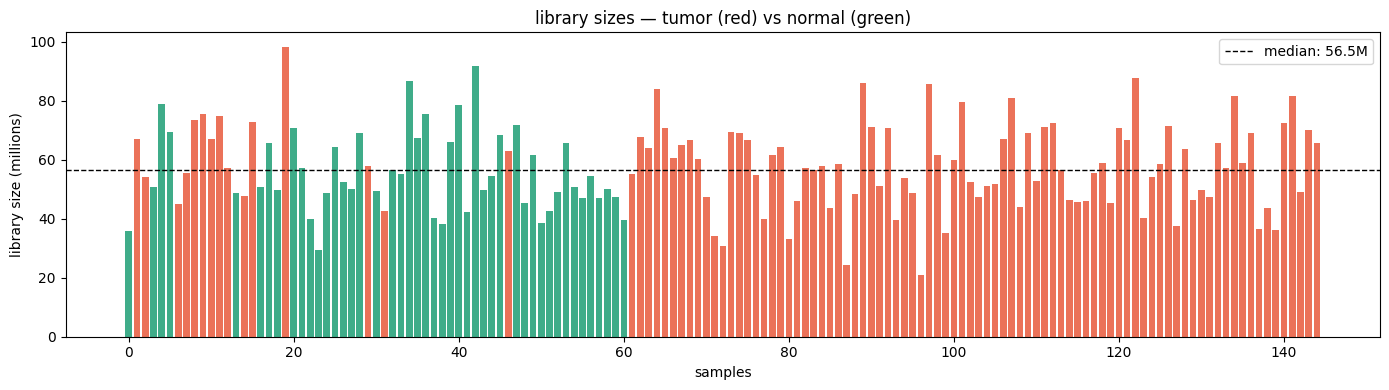

In [16]:
lib_sizes = counts_filtered.sum(axis=0) / 1e6

# safer color mapping with a default fallback
colors = []
for s in lib_sizes.index:
    match = meta[meta["case_id"] == s]["sample_type"].values
    if len(match) > 0 and match[0] == "Primary Tumor":
        colors.append("#E8593C")
    elif len(match) > 0 and match[0] == "Solid Tissue Normal":
        colors.append("#1D9E75")
    else:
        colors.append("#999999")

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(lib_sizes)), lib_sizes.values, color=colors, width=0.8, alpha=0.85)
ax.set_xlabel("samples")
ax.set_ylabel("library size (millions)")
ax.set_title("library sizes — tumor (red) vs normal (green)")
ax.axhline(lib_sizes.median(), color="black", linestyle="--", linewidth=1, label=f"median: {lib_sizes.median():.1f}M")
ax.legend()
plt.tight_layout()
plt.savefig(f"{base}/library_sizes.png", dpi=150)
plt.show()

In [ ]:
# samples with library size beyond 3 standard deviations are suspicious

mean = lib_sizes.mean()
std = lib_sizes.std()

outliers = lib_sizes[(lib_sizes < mean - 3*std) | (lib_sizes > mean + 3*std)]
print(f"outlier samples: {len(outliers)}")
print(outliers)

outlier samples: 0
Series([], dtype: float64)


In [ ]:
# dropping outlier samples if any

if len(outliers) > 0:
    counts_filtered = counts_filtered.drop(columns=outliers.index, errors="ignore")
    meta = meta[~meta["case_id"].isin(outliers.index)]
    print(f"removed {len(outliers)} outlier samples")
else:
    print("no outliers found, all samples kept")

print(f"\nfinal matrix shape: {counts_filtered.shape}")
print(meta["sample_type"].value_counts())

counts_filtered.to_csv(f"{base}/counts/brca_counts_filtered.csv")
meta.to_csv(f"{base}/clinical/brca_metadata_filtered.csv", index=False)
print("\nstage 2 done, files saved")

no outliers found, all samples kept

final matrix shape: (26575, 145)
sample_type
Primary Tumor          100
Solid Tissue Normal     50
Name: count, dtype: int64

stage 2 done, files saved


Stage 3


In [ ]:
!pip install pydeseq2 -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pydeseq2.preprocessing import deseq2_norm

base = "/content/drive/MyDrive/brca_project"

counts = pd.read_csv(f"{base}/counts/brca_counts_filtered.csv", index_col=0)
meta = pd.read_csv(f"{base}/clinical/brca_metadata_filtered.csv")

print(counts.shape)
print(meta["sample_type"].value_counts())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 6.1 MB/s eta 0:00:00
(26575, 145)
sample_type
Primary Tumor          100
Solid Tissue Normal     50
Name: count, dtype: int64


In [ ]:
# TPM normalizes for gene length + sequencing depth
# need gene lengths for this — using median gene length of 1000bp as approximation
# since we dont have GTF here, TPM here is for visualization only

def counts_to_tpm(count_df):
    # approximate gene length 1000bp for all genes (common practice without GTF)
    rpk = count_df * 1000  # reads per kilobase
    per_million = rpk.sum(axis=0) / 1e6
    tpm = rpk.div(per_million, axis=1)
    return tpm

tpm = counts_to_tpm(counts)
print("TPM matrix shape:", tpm.shape)
print("\nTPM stats:")
print(tpm.stack().describe())

TPM matrix shape: (26575, 145)

TPM stats:
count    3.853375e+06
mean     3.762935e+01
std      2.375332e+02
min      0.000000e+00
25%      2.079603e-01
50%      2.689097e+00
75%      2.817662e+01
max      8.225064e+04
dtype: float64


In [ ]:
# VST (variance stabilizing transform) is what we actually use for
# PCA, heatmaps and clustering — stabilizes variance across genes

# pydeseq2 expects samples as rows, genes as columns
counts_t = counts.T.astype(int)

# run normalization
vst_counts, size_factors = deseq2_norm(counts_t)

vst_df = pd.DataFrame(
    np.log2(vst_counts + 1),
    index=counts_t.index,
    columns=counts_t.columns
)

print("VST matrix shape:", vst_df.shape)
print("\nsize factors (should be close to 1.0):")
print(pd.Series(size_factors, index=counts_t.index).describe())

VST matrix shape: (145, 26575)

size factors (should be close to 1.0):
count    145.000000
mean       1.044105
std        0.305812
min        0.336804
25%        0.824206
50%        1.035624
75%        1.239423
max        2.141349
dtype: float64


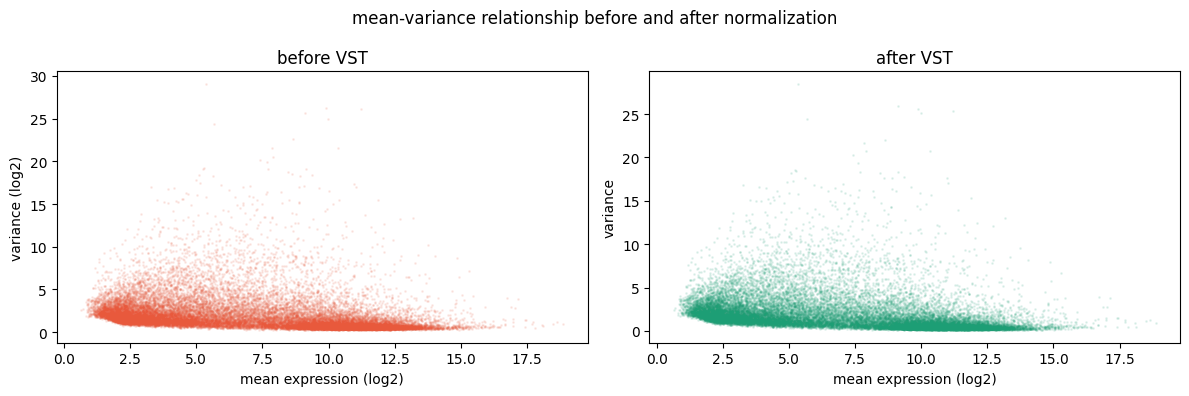

In [ ]:
# this shows VST worked — variance should be flat across mean expression levels

raw_mean = np.log2(counts + 1).mean(axis=1)
raw_var = np.log2(counts + 1).var(axis=1)

vst_mean = vst_df.mean(axis=0)
vst_var = vst_df.var(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(raw_mean, raw_var, alpha=0.1, s=1, color="#E8593C")
axes[0].set_xlabel("mean expression (log2)")
axes[0].set_ylabel("variance (log2)")
axes[0].set_title("before VST")

axes[1].scatter(vst_mean, vst_var, alpha=0.1, s=1, color="#1D9E75")
axes[1].set_xlabel("mean expression (log2)")
axes[1].set_ylabel("variance")
axes[1].set_title("after VST")

plt.suptitle("mean-variance relationship before and after normalization")
plt.tight_layout()
plt.savefig(f"{base}/mean_variance.png", dpi=150)
plt.show()

In [ ]:
vst_df.to_csv(f"{base}/counts/brca_vst_normalized.csv")
tpm.to_csv(f"{base}/counts/brca_tpm.csv")

print("stage 3 done")
print("VST saved for PCA/heatmap in stage 4")
print("TPM saved for visualization")

stage 3 done
VST saved for PCA/heatmap in stage 4
TPM saved for visualization


Stage 4

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

base = "/content/drive/MyDrive/brca_project"

vst = pd.read_csv(f"{base}/counts/brca_vst_normalized.csv", index_col=0)
meta = pd.read_csv(f"{base}/clinical/brca_metadata_filtered.csv")

print(vst.shape)
print(meta["sample_type"].value_counts())

(145, 26575)
sample_type
Primary Tumor          100
Solid Tissue Normal     50
Name: count, dtype: int64


In [ ]:
# PCA on VST normalized data
# samples as rows, genes as columns — already in that format

scaler = StandardScaler()
scaled = scaler.fit_transform(vst)

pca = PCA(n_components=10)
pca_result = pca.fit_transform(scaled)

pca_df = pd.DataFrame(pca_result[:, :2], columns=["PC1", "PC2"], index=vst.index)
pca_df = pca_df.merge(meta[["case_id", "sample_type"]], left_index=True, right_on="case_id")

print("variance explained:")
for i, var in enumerate(pca.explained_variance_ratio_[:5]):
    print(f"  PC{i+1}: {var*100:.1f}%")

variance explained:
  PC1: 14.9%
  PC2: 9.2%
  PC3: 7.1%
  PC4: 5.0%
  PC5: 3.7%


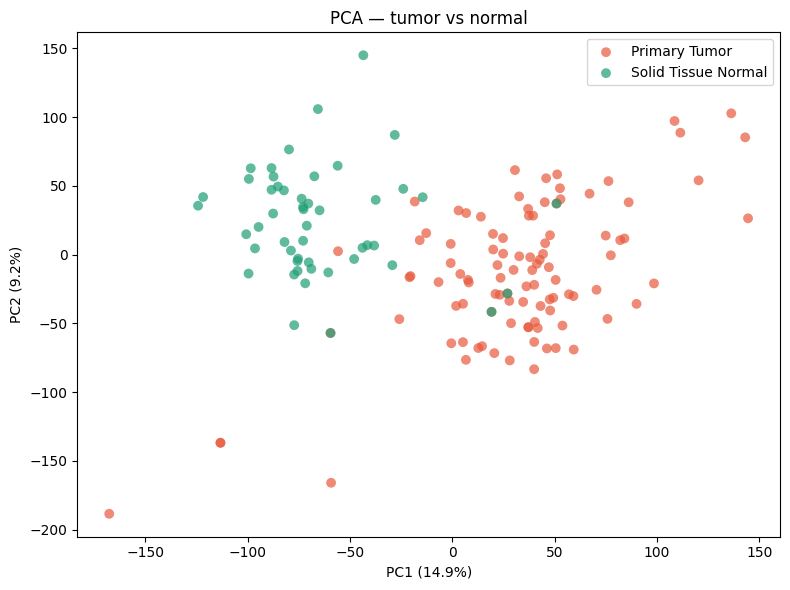

In [ ]:
colors = {"Primary Tumor": "#E8593C", "Solid Tissue Normal": "#1D9E75"}

fig, ax = plt.subplots(figsize=(8, 6))

for stype, group in pca_df.groupby("sample_type"):
    ax.scatter(
        group["PC1"], group["PC2"],
        label=stype, color=colors[stype],
        alpha=0.7, s=50, edgecolors="none"
    )

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("PCA — tumor vs normal")
ax.legend()
plt.tight_layout()
plt.savefig(f"{base}/pca_plot.png", dpi=150)
plt.show()

In [ ]:
# picking top 500 most variable genes for heatmap
# using all 26k genes would just be noise

gene_var = vst.var(axis=0)
top_genes = gene_var.sort_values(ascending=False).head(500).index
vst_top = vst[top_genes]

print("top 500 variable genes selected")
print(vst_top.shape)

top 500 variable genes selected
(145, 500)


/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


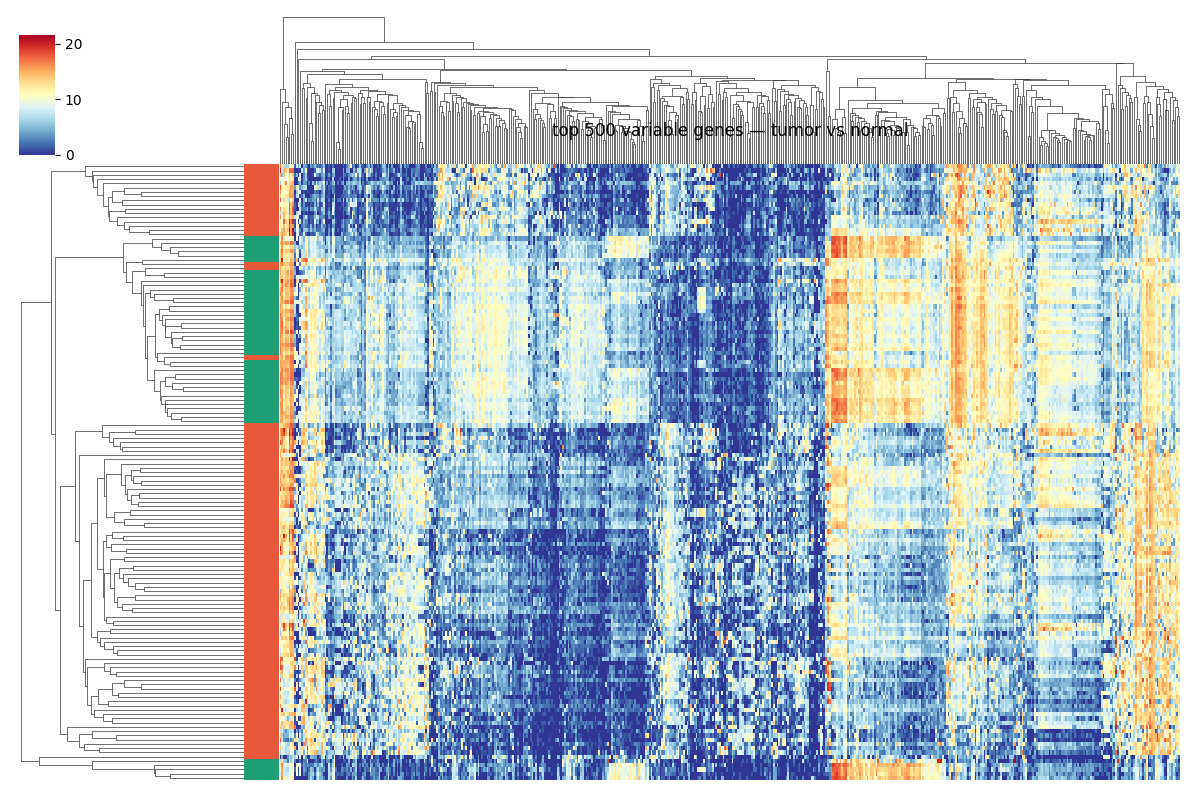

In [ ]:
# drop duplicate case_ids from meta first
meta_unique = meta.drop_duplicates("case_id").set_index("case_id")

vst_top_aligned = vst_top.loc[vst.index]

row_colors = vst.index.map(
    meta_unique["sample_type"]
).map({
    "Primary Tumor": "#E8593C",
    "Solid Tissue Normal": "#1D9E75"
}).fillna("#999999").values

g = sns.clustermap(
    vst_top_aligned,
    row_cluster=True,
    col_cluster=True,
    row_colors=row_colors,
    cmap="RdYlBu_r",
    figsize=(12, 8),
    xticklabels=False,
    yticklabels=False,
    cbar_pos=(0.02, 0.8, 0.03, 0.15)
)

g.ax_heatmap.set_title("top 500 variable genes — tumor vs normal", pad=20)
plt.savefig(f"{base}/heatmap.png", dpi=150)
plt.show()

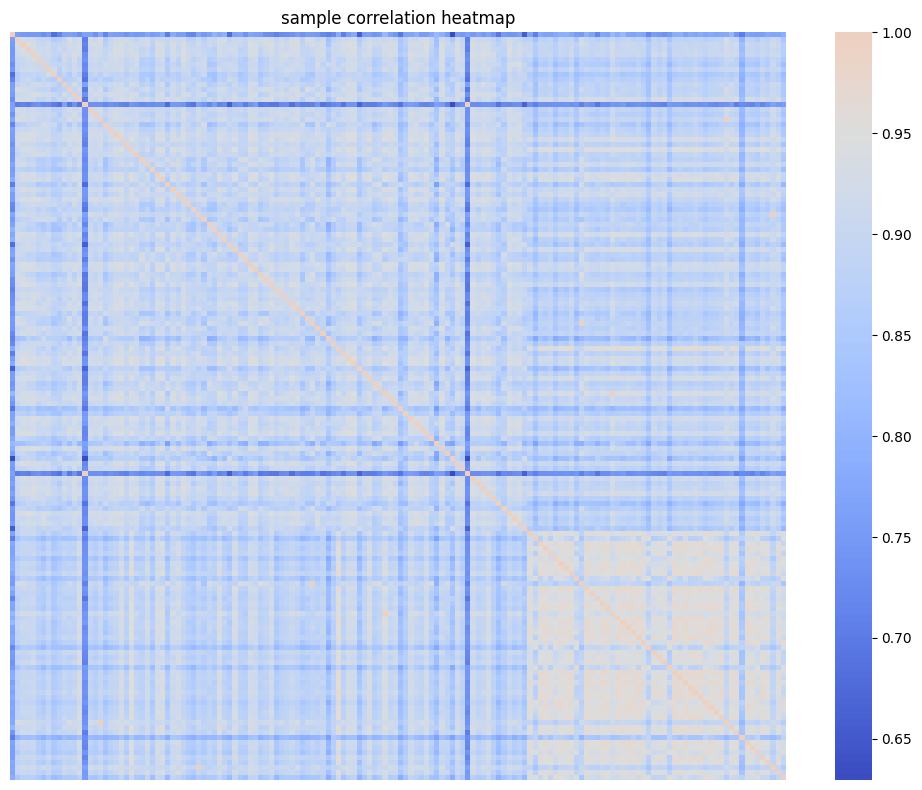

In [ ]:
# sample-sample correlation — sanity check
# tumor samples should correlate with each other, same for normal

corr = vst.T.corr()

# sort by sample type so tumor and normal are grouped
sample_order = meta.sort_values("sample_type")["case_id"].tolist()
sample_order = [s for s in sample_order if s in corr.index]
corr = corr.loc[sample_order, sample_order]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0.95,
            xticklabels=False, yticklabels=False, ax=ax)
ax.set_title("sample correlation heatmap")
plt.tight_layout()
plt.savefig(f"{base}/correlation_heatmap.png", dpi=150)
plt.show()

Stage 5

In [ ]:
!pip install pydeseq2 -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

base = "/content/drive/MyDrive/brca_project"

counts = pd.read_csv(f"{base}/counts/brca_counts_filtered.csv", index_col=0)
meta = pd.read_csv(f"{base}/clinical/brca_metadata_filtered.csv")

# transpose — counts was saved as genes x samples
counts = counts.T

meta = meta.drop_duplicates("case_id").set_index("case_id")
common = counts.index.intersection(meta.index)
print(f"common samples: {len(common)}")

counts = counts.loc[common]
meta = meta.loc[common]

meta["condition"] = meta["sample_type"].map({
    "Primary Tumor": "tumor",
    "Solid Tissue Normal": "normal"
})

print(counts.shape)
print(meta["condition"].value_counts())

common samples: 145
(145, 26575)
condition
tumor     99
normal    46
Name: count, dtype: int64


In [ ]:
# pydeseq2 expects integer counts
counts_int = counts.astype(int)

dds = DeseqDataSet(
    counts=counts_int,
    metadata=meta[["condition"]],
    design_factors="condition",
    refit_cooks=True
)

dds.deseq2()
print("DESeq2 done")

/tmp/ipykernel_7936/1172539939.py:4: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.25 seconds.

Fitting dispersions...
... done in 63.85 seconds.

Fitting dispersion trend curve...
... done in 1.14 seconds.

Fitting MAP dispersions...
... done in 65.51 seconds.

Fitting LFCs...
... done in 31.69 seconds.

Calculating cook's distance...
... done in 0.47 seconds.

Replacing 3438 outlier genes.

Fitting dispersions...
... done in 8.49 seconds.

Fitting MAP dispersions...
... done in 6.56 seconds.

Fitting LFCs...
... done in 5.41 seconds.



DESeq2 done


In [ ]:
# tumor vs normal — positive log2FC means higher in tumor
stat_res = DeseqStats(dds, contrast=["condition", "tumor", "normal"])
stat_res.summary()

results = stat_res.results_df
results = results.dropna()
print(f"total genes tested: {len(results)}")
print(results.head())

Running Wald tests...


Log2 fold change & Wald test p-value: condition tumor vs normal
                       baseMean  log2FoldChange     lfcSE       stat  \
gene_id                                                                
ENSG00000000003.15  3272.998148       -0.643516  0.142563  -4.513894   
ENSG00000000005.6    247.037213       -4.204252  0.354507 -11.859429   
ENSG00000000419.13  2106.313185        0.429947  0.084636   5.079926   
ENSG00000000457.14  1469.911382        0.418505  0.102884   4.067752   
ENSG00000000460.17   608.990134        1.447749  0.127575  11.348221   
...                         ...             ...       ...        ...   
ENSG00000288658.1     16.026442       -0.044695  0.304466  -0.146798   
ENSG00000288663.1     27.344623        0.355937  0.152111   2.339980   
ENSG00000288670.1    428.860026       -0.133372  0.134213  -0.993732   
ENSG00000288674.1      9.801168       -0.461001  0.180809  -2.549654   
ENSG00000288675.1     24.560331        1.363010  0.196891   6.922676   


... done in 15.22 seconds.



In [ ]:
# standard thresholds used in most papers
# |log2FC| > 1.5 and padj < 0.05

degs = results[
    (abs(results["log2FoldChange"]) > 1.5) &
    (results["padj"] < 0.05)
]

upregulated   = degs[degs["log2FoldChange"] > 0]
downregulated = degs[degs["log2FoldChange"] < 0]

print(f"total DEGs:     {len(degs)}")
print(f"upregulated:    {len(upregulated)}")
print(f"downregulated:  {len(downregulated)}")

total DEGs:     4092
upregulated:    2319
downregulated:  1773


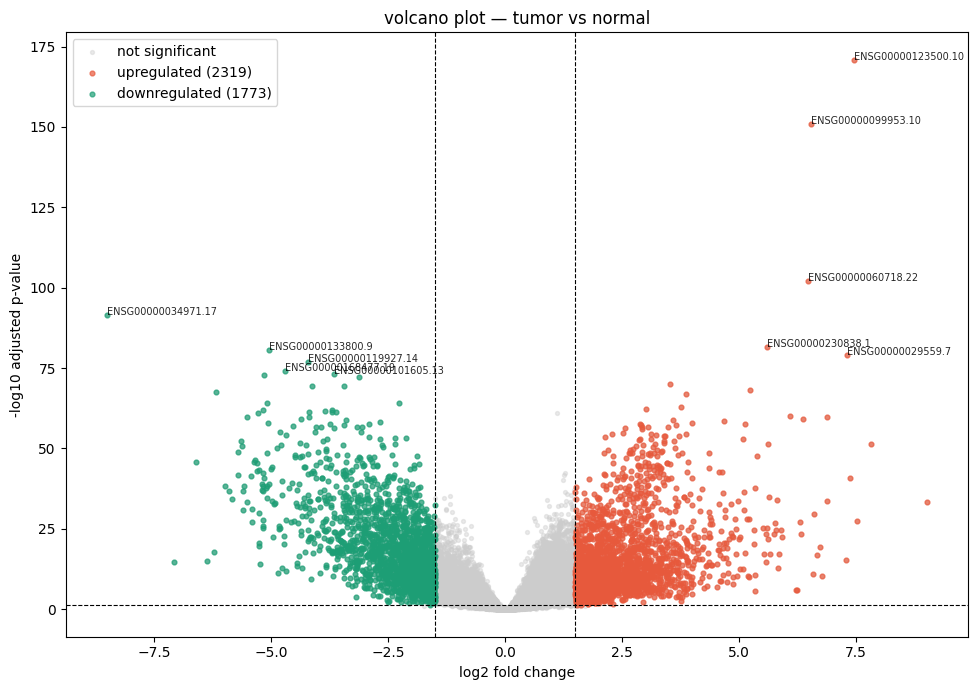

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

# background genes
ax.scatter(results["log2FoldChange"], -np.log10(results["padj"]),
           color="#cccccc", alpha=0.4, s=8, label="not significant")

# significant genes
ax.scatter(upregulated["log2FoldChange"], -np.log10(upregulated["padj"]),
           color="#E8593C", alpha=0.7, s=12, label=f"upregulated ({len(upregulated)})")

ax.scatter(downregulated["log2FoldChange"], -np.log10(downregulated["padj"]),
           color="#1D9E75", alpha=0.7, s=12, label=f"downregulated ({len(downregulated)})")

# threshold lines
ax.axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=0.8)
ax.axvline(1.5,  color="black", linestyle="--", linewidth=0.8)
ax.axvline(-1.5, color="black", linestyle="--", linewidth=0.8)

# label top 10 genes
top10 = degs.reindex(degs["padj"].nsmallest(10).index)
for gene, row in top10.iterrows():
    ax.annotate(gene, (row["log2FoldChange"], -np.log10(row["padj"])),
                fontsize=7, alpha=0.85)

ax.set_xlabel("log2 fold change")
ax.set_ylabel("-log10 adjusted p-value")
ax.set_title("volcano plot — tumor vs normal")
ax.legend()
plt.tight_layout()
plt.savefig(f"{base}/volcano_plot.png", dpi=150)
plt.show()

In [ ]:
import os

os.makedirs(f"{base}/results", exist_ok=True)

results.to_csv(f"{base}/results/all_genes_deseq2.csv")
degs.to_csv(f"{base}/results/DEGs.csv")

print("stage 5 done")
print(f"DEGs saved: {len(degs)}")

stage 5 done
DEGs saved: 4092


Stage 6


In [ ]:
!pip install gseapy mygene -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gseapy as gp
import mygene

base = "/content/drive/MyDrive/brca_project"

results = pd.read_csv(f"{base}/results/all_genes_deseq2.csv", index_col=0)
degs = pd.read_csv(f"{base}/results/DEGs.csv", index_col=0)

print("results shape:", results.shape)
print("DEGs:", len(degs))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 634.7/634.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.2 MB/s eta 0:00:00
results shape: (26575, 6)
DEGs: 4092


In [ ]:
# strip version numbers from ensembl ids (e.g. ENSG00000000003.15 -> ENSG00000000003)
results.index = results.index.str.split(".").str[0]
degs.index = degs.index.str.split(".").str[0]

mg = mygene.MyGeneInfo()
gene_ids = results.index.tolist()

# query in batches
info = mg.querymany(gene_ids, scopes="ensembl.gene", fields="symbol", species="human", as_dataframe=True)
info = info[~info.index.duplicated(keep="first")]
info = info.dropna(subset=["symbol"])

# map symbols back
results["gene_symbol"] = results.index.map(info["symbol"])
degs["gene_symbol"] = degs.index.map(info["symbol"])

results = results.dropna(subset=["gene_symbol"])
degs = degs.dropna(subset=["gene_symbol"])

print(f"genes with symbols: {len(results)}")
print(degs["gene_symbol"].head(10).tolist())

INFO:biothings.client:querying 1-1000 ...
INFO:biothings.client:querying 1001-2000 ...
INFO:biothings.client:querying 2001-3000 ...
INFO:biothings.client:querying 3001-4000 ...
INFO:biothings.client:querying 4001-5000 ...
INFO:biothings.client:querying 5001-6000 ...
INFO:biothings.client:querying 6001-7000 ...
INFO:biothings.client:querying 7001-8000 ...
INFO:biothings.client:querying 8001-9000 ...
INFO:biothings.client:querying 9001-10000 ...
INFO:biothings.client:querying 10001-11000 ...
INFO:biothings.client:querying 11001-12000 ...
INFO:biothings.client:querying 12001-13000 ...
INFO:biothings.client:querying 13001-14000 ...
INFO:biothings.client:querying 14001-15000 ...
INFO:biothings.client:querying 15001-16000 ...
INFO:biothings.client:querying 16001-17000 ...
INFO:biothings.client:querying 17001-18000 ...
INFO:biothings.client:querying 18001-19000 ...
INFO:biothings.client:querying 19001-20000 ...
INFO:biothings.client:querying 20001-21000 ...
INFO:biothings.client:querying 2100

genes with symbols: 22779
['TNMD', 'AOC1', 'KLHL13', 'CYP26B1', 'DBNDD1', 'TFPI', 'HSPB6', 'PDK4', 'ZMYND10', 'ABCB5']


In [ ]:
# rank by sign(log2FC) * -log10(padj)
# this gives highly significant + highly changed genes the highest rank

results["rank_score"] = np.sign(results["log2FoldChange"]) * -np.log10(results["padj"] + 1e-300)
ranked = results.dropna(subset=["rank_score"]).sort_values("rank_score", ascending=False)
ranked = ranked.drop_duplicates("gene_symbol")

rank_series = ranked.set_index("gene_symbol")["rank_score"]
print(f"ranked genes: {len(rank_series)}")
print(rank_series.head())

ranked genes: 22738
gene_symbol
COL10A1      170.891370
MMP11        150.887430
COL11A1      101.993606
LINC01614     81.702013
IBSP          79.135947
Name: rank_score, dtype: float64


In [ ]:
# using hallmark gene sets — cleaner and more interpretable than full MSigDB
# takes 2-3 min

gsea_res = gp.prerank(
    rnk=rank_series,
    gene_sets="MSigDB_Hallmark_2020",
    outdir=f"{base}/gsea_results",
    permutation_num=100,
    seed=42,
    verbose=False
)

gsea_df = gsea_res.res2d.sort_values("FDR q-val")
print(f"pathways tested: {len(gsea_df)}")
print(gsea_df[["Term", "NES", "FDR q-val"]].head(10))

2026-06-07 16:58:47,781 [WARNING] Duplicated values found in preranked stats: 4.15% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


pathways tested: 50
                        Term       NES  FDR q-val
0            G2-M Checkpoint  2.675736       0.01
1                E2F Targets  2.660472       0.01
2               Adipogenesis   -2.4796       0.01
3             Myc Targets V1  2.189328       0.01
4                 Myogenesis -2.094366       0.01
5           mTORC1 Signaling  1.970777       0.01
6             UV Response Dn -1.874344       0.01
7             Myc Targets V2  1.858957       0.01
8  Unfolded Protein Response  1.831563       0.01
9                 DNA Repair    1.8227       0.01


In [ ]:
# over representation analysis on significant DEGs
# using GO biological process

deg_symbols = degs["gene_symbol"].dropna().tolist()

ora = gp.enrichr(
    gene_list=deg_symbols,
    gene_sets=["GO_Biological_Process_2023", "KEGG_2021_Human"],
    outdir=f"{base}/ora_results",
    cutoff=0.05
)

ora_df = ora.results.sort_values("Adjusted P-value")
print(ora_df[["Gene_set", "Term", "Adjusted P-value", "Overlap"]].head(15))

                        Gene_set  \
0     GO_Biological_Process_2023   
4397             KEGG_2021_Human   
1     GO_Biological_Process_2023   
2     GO_Biological_Process_2023   
4398             KEGG_2021_Human   
4399             KEGG_2021_Human   
4400             KEGG_2021_Human   
6     GO_Biological_Process_2023   
5     GO_Biological_Process_2023   
4     GO_Biological_Process_2023   
3     GO_Biological_Process_2023   
4401             KEGG_2021_Human   
7     GO_Biological_Process_2023   
8     GO_Biological_Process_2023   
4402             KEGG_2021_Human   

                                                   Term  Adjusted P-value  \
0        Extracellular Matrix Organization (GO:0030198)          0.000011   
4397                       Systemic lupus erythematosus          0.000021   
1     Extracellular Structure Organization (GO:0043062)          0.000047   
2     External Encapsulating Structure Organization ...          0.000137   
4398                                  

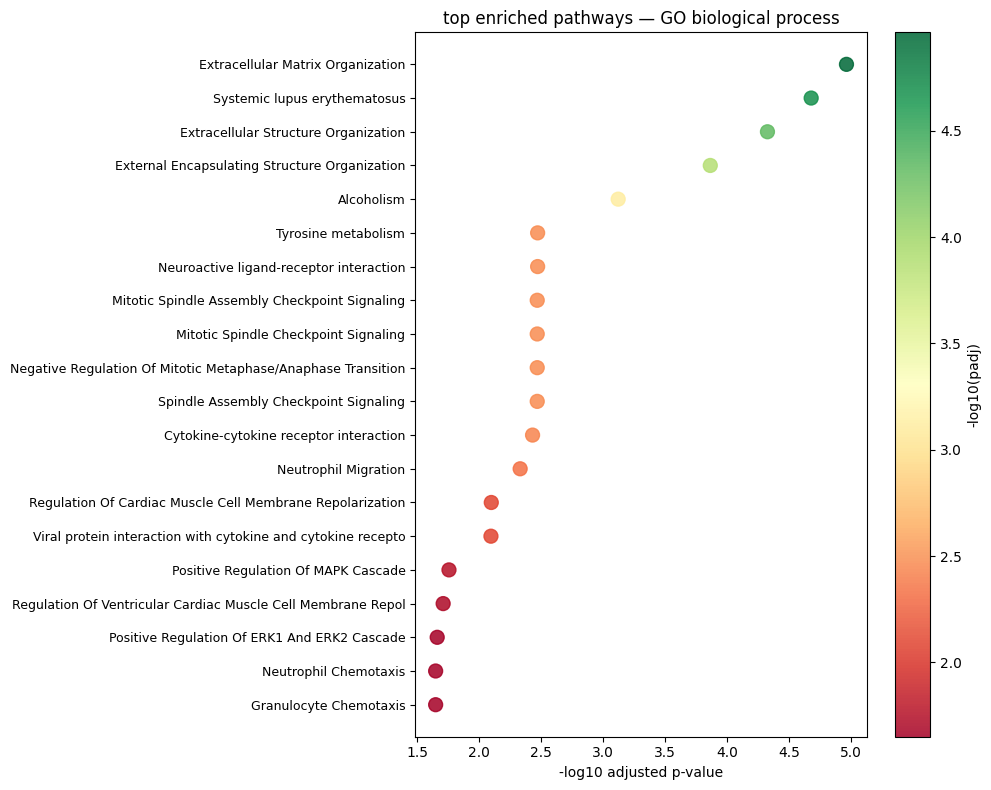

In [ ]:
top_pathways = ora_df[ora_df["Adjusted P-value"] < 0.05].head(20).copy()
top_pathways["-log10(padj)"] = -np.log10(top_pathways["Adjusted P-value"])
top_pathways = top_pathways.sort_values("-log10(padj)")

# shorten long term names
top_pathways["Term"] = top_pathways["Term"].str.split("(").str[0].str.strip()
top_pathways["Term"] = top_pathways["Term"].str[:60]

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    top_pathways["-log10(padj)"],
    range(len(top_pathways)),
    c=top_pathways["-log10(padj)"],
    cmap="RdYlGn",
    s=100, alpha=0.85
)

ax.set_yticks(range(len(top_pathways)))
ax.set_yticklabels(top_pathways["Term"], fontsize=9)
ax.set_xlabel("-log10 adjusted p-value")
ax.set_title("top enriched pathways — GO biological process")
plt.colorbar(scatter, ax=ax, label="-log10(padj)")
plt.tight_layout()
plt.savefig(f"{base}/enrichment_dotplot.png", dpi=150)
plt.show()

In [ ]:
gsea_df.to_csv(f"{base}/results/gsea_results.csv")
ora_df.to_csv(f"{base}/results/ora_results.csv")
degs.to_csv(f"{base}/results/DEGs_with_symbols.csv")

print("stage 6 done")

stage 6 done


## Google Colab is available in VS Code!
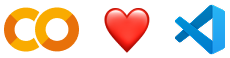

Try the new [Google Colab extension](https://marketplace.visualstudio.com/items?itemName=Google.colab) for Visual Studio Code. You can get up and running in just a few clicks:

*  In VS Code, open the ***Extensions*** view and search for 'Google Colab' to install.
*  Open the kernel selector by creating or opening any `.ipynb` notebook file in your local workspace and either running a cell or clicking the ***Select Kernel*** button in the top right.
*  Click ***Colab*** and then select your desired runtime, sign in with your Google account, and you're all set!

See more details in our [announcement blog here](https://developers.googleblog.com/google-colab-is-coming-to-vs-code).

## Access popular AI models via Google-Colab-AI Without an API Key
All users have access to most popular LLMs via the `google-colab-ai` Python library, and paid users have access to a wider selection of models. For more details, refer to the [getting started with google colab ai](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb).



In [ ]:
from google.colab import ai
response = ai.generate_text("What is the capital of France?")

## Explore the Gemini API
The Gemini API gives you access to Gemini models created by Google DeepMind. Gemini models are built from the ground up to be multimodal, so you can reason seamlessly across text, images, code, and audio.

**How to get started?**
*  Go to [Google AI Studio](https://aistudio.google.com/) and log in with your Google account.
*  [Create an API key](https://aistudio.google.com/app/apikey).
* Use a quickstart for [Python](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started.ipynb), or call the REST API using [curl](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/rest/Prompting_REST.ipynb).

**Discover Gemini's advanced capabilities**
*  Play with Gemini [multimodal outputs](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Image-out.ipynb), mixing text and images in an iterative way.
*  Discover the [multimodal Live API](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_LiveAPI.ipynb ) (demo [here](https://aistudio.google.com/live)).
*  Learn how to [analyze images and detect items in your pictures](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Spatial_understanding.ipynb") using Gemini (bonus, there's a [3D version](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Spatial_understanding_3d.ipynb) as well!).
*  Unlock the power of [Gemini thinking model](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_thinking.ipynb), capable of solving complex task with its inner thoughts.
      
**Explore complex use cases**
*  Use [Gemini grounding capabilities](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Search_grounding_for_research_report.ipynb) to create a report on a company based on what the model can find on internet.
*  Extract [invoices and form data from PDF](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Pdf_structured_outputs_on_invoices_and_forms.ipynb) in a structured way.
*  Create [illustrations based on a whole book](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Book_illustration.ipynb) using Gemini large context window and Imagen.

To learn more, check out the [Gemini cookbook](https://github.com/google-gemini/cookbook) or visit the [Gemini API documentation](https://ai.google.dev/docs/).


Colab now has AI features powered by [Gemini](https://gemini.google.com). The video below provides information on how to use these features, whether you're new to Python, or a seasoned veteran.

<center>
  <a href="https://www.youtube.com/watch?v=V7RXyqFUR98" target="_blank">
  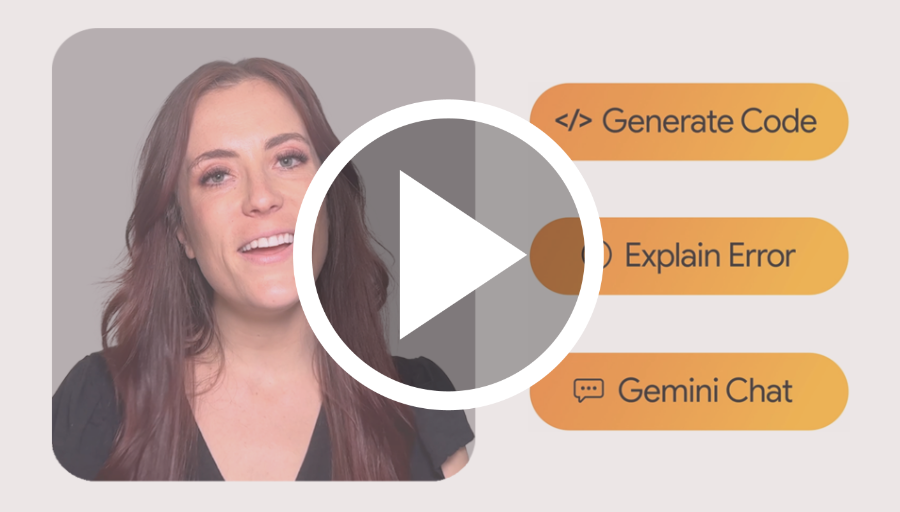
  </a>
</center>

<div class="markdown-google-sans">
  <h2>What is Colab?</h2>
</div>

Colab, or "Colaboratory", allows you to write and execute Python in your browser, with
- Zero configuration required
- Access to GPUs free of charge
- Easy sharing

Whether you're a **student**, a **data scientist** or an **AI researcher**, Colab can make your work easier. Watch [Introduction to Colab](https://www.youtube.com/watch?v=inN8seMm7UI) or [Colab Features You May Have Missed](https://www.youtube.com/watch?v=rNgswRZ2C1Y) to learn more, or just get started below!

<div class="markdown-google-sans">

## **Getting started**
</div>

The document you are reading is not a static web page, but an interactive environment called a **Colab notebook** that lets you write and execute code.

For example, here is a **code cell** with a short Python script that computes a value, stores it in a variable, and prints the result:

In [ ]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

To execute the code in the above cell, select it with a click and then either press the play button to the left of the code, or use the keyboard shortcut "Command/Ctrl+Enter". To edit the code, just click the cell and start editing.

Variables that you define in one cell can later be used in other cells:

In [ ]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

Colab notebooks allow you to combine **executable code** and **rich text** in a single document, along with **images**, **HTML**, **LaTeX** and more. When you create your own Colab notebooks, they are stored in your Google Drive account. You can easily share your Colab notebooks with co-workers or friends, allowing them to comment on your notebooks or even edit them. To learn more, see [Overview of Colab](/notebooks/basic_features_overview.ipynb). To create a new Colab notebook you can use the File menu above, or use the following link: [create a new Colab notebook](http://colab.research.google.com#create=true).

Colab notebooks are Jupyter notebooks that are hosted by Colab. To learn more about the Jupyter project, see [jupyter.org](https://www.jupyter.org).

<div class="markdown-google-sans">

## Data science
</div>

With Colab you can harness the full power of popular Python libraries to analyze and visualize data. The code cell below uses **numpy** to generate some random data, and uses **matplotlib** to visualize it. To edit the code, just click the cell and start editing.

You can import your own data into Colab notebooks from your Google Drive account, including from spreadsheets, as well as from Github and many other sources. To learn more about importing data, and how Colab can be used for data science, see the links below under [Working with Data](#working-with-data).

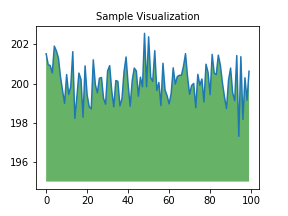

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Colab notebooks execute code on Google's cloud servers, meaning you can leverage the power of Google hardware, including [GPUs and TPUs](#using-accelerated-hardware), regardless of the power of your machine. All you need is a browser.

For example, if you find yourself waiting for **pandas** code to finish running and want to go faster, you can switch to a GPU Runtime and use libraries like [RAPIDS cuDF](https://rapids.ai/cudf-pandas) that provide zero-code-change acceleration.

To learn more about accelerating pandas on Colab, see the [10 minute guide](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb) or
 [US stock market data analysis demo](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb).

<div class="markdown-google-sans">

## Machine learning
</div>

With Colab you can import an image dataset, train an image classifier on it, and evaluate the model, all in just [a few lines of code](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb).

Colab is used extensively in the machine learning community with applications including:
- Getting started with TensorFlow
- Developing and training neural networks
- Experimenting with TPUs
- Disseminating AI research
- Creating tutorials

To see sample Colab notebooks that demonstrate machine learning applications, see the [machine learning examples](#machine-learning-examples) below.

<div class="markdown-google-sans">

## More Resources

### Working with Notebooks in Colab

</div>

- [Overview of Colab](/notebooks/basic_features_overview.ipynb)
- [Guide to Markdown](/notebooks/markdown_guide.ipynb)
- [Importing libraries and installing dependencies](/notebooks/snippets/importing_libraries.ipynb)
- [Saving and loading notebooks in GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Interactive forms](/notebooks/forms.ipynb)
- [Interactive widgets](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Working with Data
</div>

- [Loading data: Drive, Sheets, and Google Cloud Storage](/notebooks/io.ipynb)
- [Charts: visualizing data](/notebooks/charts.ipynb)
- [Getting started with BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Machine Learning

<div>

These are a few of the notebooks related to Machine Learning, including Google's online Machine Learning course. See the [full course website](https://developers.google.com/machine-learning/crash-course/) for more.
- [Intro to Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Intro to RAPIDS cuDF to accelerate pandas](https://nvda.ws/rapids-cudf)
- [Getting Started with cuML's accelerator mode](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Using Accelerated Hardware
</div>

- [Train a CNN to classify handwritten digits on the MNIST dataset using Flax NNX API](https://colab.research.google.com/github/google/flax/blob/main/docs_nnx/mnist_tutorial.ipynb)
- [Train a Vision Transformer (ViT) for image classification with JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_Vision_transformer.ipynb)
- [Text classification with a transformer language model using JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_transformer_text_classification.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Featured examples

</div>

- [Train a miniGPT language model with JAX AI Stack](https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html)
- [LoRA/QLoRA finetuning for LLM using Tunix](https://github.com/google/tunix/blob/main/examples/qlora_gemma.ipynb)
- [Parameter-efficient fine-tuning of Gemma with LoRA and QLoRA](https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/)
- [Loading Hugging Face Transformers Checkpoints](https://keras.io/keras_hub/guides/hugging_face_keras_integration/)
- [8-bit Integer Quantization in Keras](https://keras.io/guides/int8_quantization_in_keras/)
- [Float8 training and inference with a simple Transformer model](https://keras.io/examples/keras_recipes/float8_training_and_inference_with_transformer/)
- [Pretraining a Transformer from scratch with KerasHub](https://keras.io/keras_hub/guides/transformer_pretraining/)
- [Simple MNIST convnet](https://keras.io/examples/vision/mnist_convnet/)
- [Image classification from scratch using Keras 3](https://keras.io/examples/vision/image_classification_from_scratch/)
- [Image Classification with KerasHub](https://keras.io/keras_hub/guides/classification_with_keras_hub/)
